Another approach to calculate epsitasis between v families/genes is to use amino acid preference, similar to the DMS approach.
(Example: https://elifesciences.org/articles/34420)

In this approach, we take all of the selection factors (20) for amino acids per site (same amino acid will always be neutral 1), and normalize them so that they sum to 1.
This turns our selection factors to amino acids preference, and allows us to compare directly between sites with different germline amino acids.
Limitations:
- It assumes all 20 DASM predictions per site are good. In other cases we limit this to only amino acid mutation that can be reached by one nucleotide away.
- It allows us to compare v genes and not full v families, pssobily limiting the prediction accuracy.

Ultimately, looking for entrenchemnt, the previous approach of different analysis fro germline identical and germline divergent sites seemed to work better.

In [1]:

from tqdm.auto import tqdm
tqdm.pandas()

import os
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

from utils import add_germline_information, add_column_aa_one_mutation_away_from_codon

from dnsmex import dasm_zoo
from dnsmex.dasm_oe import write_sites_oe
from dnsmex.local import localify
import tqdm

from dnsmex.local import localify

figures_dir = localify("FIGURES_DIR")

## Prep data - Rodriguez dataset

In [2]:
%%bash
## get counts of V and J genes
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 11 | cut -d '-' -f 1 | sort | uniq -c | sort -nr
echo "---"
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 20 | cut -d '*' -f 1 | sort | uniq -c | sort -nr

   9985 IGHV3
   5246 IGHV4
   4328 IGHV1
    944 IGHV5
    771 IGHV2
    351 IGHV6
    129 IGHV7
---
  11562 IGHJ4
   3563 IGHJ6
   2863 IGHJ5
   2825 IGHJ3
    562 IGHJ2
    379 IGHJ1


In [3]:
#dataset_name = "v1rodriguez_test"
dataset_name = "v1rodriguez"
model_name = "dasm_4m-v1jaffeCC+v1tangCC-joint"


crepe_prefix = localify(f"DASM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DASM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

try: # load data if already computed
    
    site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
    pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")
    aa_site_subs_selection_df = pd.read_csv(f"{test_output_prefix}-aa_site_subs_selection_df.csv")

except FileNotFoundError:
    if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
        dasm_zoo.write_branch_lengths(localify(f"DASM_TRAINED_MODELS_DIR/{model_name}"), dataset_name, f"{test_output_prefix}.branch_lengths_csv")


    complete_plotter, plotter_dict = write_sites_oe(
        crepe_prefix=crepe_prefix,
        dataset_name=dataset_name,
        branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
        csv_output_path=f"{test_output_prefix}-sites-oe.csv",
        fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
        min_log_prob=-4,
        #v_families=["IGHV1", "IGHV2", "IGHV3", "IGHV4", "IGHV5", "IGHV6", "IGHV7"],
        replace_title=True,
    )
    complete_plotter = complete_plotter["heavy"]

    pcp_df = complete_plotter.pcp_df.copy()
    site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
    aa_site_subs_selection_df = complete_plotter.aa_site_subs_selection_df.copy()

    pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
    site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)
    aa_site_subs_selection_df.to_csv(f"{test_output_prefix}-aa_site_subs_selection_df.csv", index=False)




Adding one_mutation_away column: 100%|██████████| 52927420/52927420 [04:09<00:00, 212388.16it/s]


<Axes: xlabel='site', ylabel='Count'>

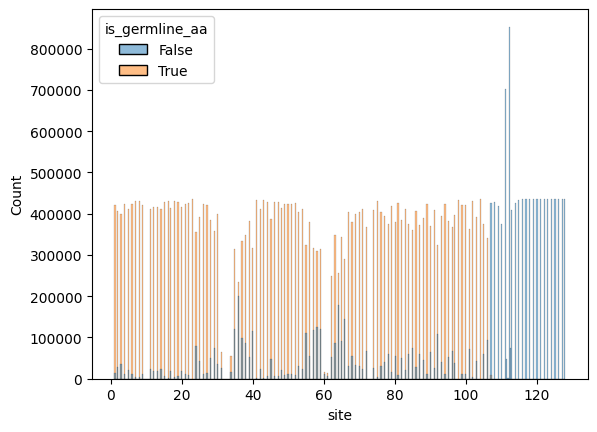

In [4]:
# add germline annotation, one mutation away annotations and tree/clonal family information
pcp_df_for_merge = pcp_df.copy()
pcp_df_for_merge = pcp_df_for_merge[['sample_id', 'family', 'depth', 'distance']]
pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index

aa_site_subs_selection_df = pd.merge(aa_site_subs_selection_df, pcp_df_for_merge, on='pcp_index', how='inner')
aa_site_subs_selection_df['log_selection_factor'] = np.log(aa_site_subs_selection_df.selection_factor)

aa_site_subs_selection_df_germline = add_germline_information(pcp_df, aa_site_subs_selection_df)
add_column_aa_one_mutation_away_from_codon(aa_site_subs_selection_df_germline)

sns.histplot(aa_site_subs_selection_df_germline, x='site', hue='is_germline_aa')

In [5]:
## load germline information
germline_codons_df = pd.read_csv(localify(f"germline/germline_codons.csv"))

In [6]:
# compare two v families - dms style
# is scaling the linear selection fators to sum to 1 the best course, or log first?
# this means we trust all of the 20 predictions for each site, even those that are more than one nucleotide away


def compare_vgenes_dms_style(aa_site_subs_selection_df_germline, germline_codons_df, v_gene1, v_gene2, limit_pcp_depth=True, figsize=(20, 6)):
    '''
    issues - this means we "believe" all of the amino acids predictions, even those that are more than one nucleotide away
    '''
    before_grouping = aa_site_subs_selection_df_germline[aa_site_subs_selection_df_germline.v_gene.isin([v_gene1, v_gene2])].copy()
    before_grouping = before_grouping[before_grouping.is_germline_codon == True]

    if limit_pcp_depth:
        # Limit to only pcps that are 2 levels away from the naive, which are likely the most reliable
        before_grouping = before_grouping[before_grouping.depth == 2]

    median_selection_factors_germline = before_grouping.groupby(['v_gene', 'site', 'parent_aa', 'selection_factor_target_aa', 'is_cdr']).selection_factor.median().reset_index().copy()
    median_selection_factors_germline['selection_factor'] = median_selection_factors_germline['selection_factor'].fillna(1)
    median_selection_factors_germline['normalized_selection_factor'] = median_selection_factors_germline.groupby(['v_gene', 'site', 'parent_aa', 'is_cdr']).selection_factor.transform(lambda x: x / x.sum())
    # compare v families
    # change the column names to describe selection direction
    median_selection_factors_1 = median_selection_factors_germline[median_selection_factors_germline.v_gene == v_gene1].copy()
    median_selection_factors_2 = median_selection_factors_germline[median_selection_factors_germline.v_gene == v_gene2].copy()

    compare_df = pd.merge(median_selection_factors_1, median_selection_factors_2, on=['site', 'selection_factor_target_aa', 'is_cdr'], how='inner', suffixes=('_1', '_2'))
    compare_df['difference_normalized_selection_factor'] = (compare_df['normalized_selection_factor_1'] - compare_df['normalized_selection_factor_2']).abs()
    compare_df['same_germline_aa'] = compare_df.parent_aa_1 == compare_df.parent_aa_2

    #plot
    fig, ax = plt.subplots(figsize=(20, 6))
    sns.scatterplot(compare_df, x='site', y='difference_normalized_selection_factor', alpha=0.5, ax=ax, hue='same_germline_aa')
    ax.set_title(f"Comparison of {v_gene1} and {v_gene2} - DMS style")
    # set x ticks every two sites
    ax.set_xticks(np.arange(compare_df.site.min()-1, compare_df.site.max()+1, 2))
    # rotate x ticks
    plt.xticks(rotation=90)
    ax.grid()
    plt.show()

    # plot 

    # First plot with scatterplot and manual regression lines
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Get the data
    x = compare_df['normalized_selection_factor_1'].values
    y = compare_df['normalized_selection_factor_2'].values

    # Plot 1: Log scale
    sns.scatterplot(data=compare_df, x='normalized_selection_factor_1', y='normalized_selection_factor_2', 
                    hue='same_germline_aa', alpha=0.5, s=20, ax=axes[0])

    # Add regression line for log scale (fit on log-transformed data)
    mask = (x > 0) & (y > 0)  # Ensure positive values for log
    x_log = np.log10(x[mask])
    y_log = np.log10(y[mask])
    slope, intercept, r, p, se = stats.linregress(x_log, y_log)

    # Create line points in log space
    x_range_log = np.linspace(x_log.min(), x_log.max(), 100)
    y_pred_log = intercept + slope * x_range_log

    # Convert back to linear space for plotting
    axes[0].plot(10**x_range_log, 10**y_pred_log, 'r-', alpha=0.8, linewidth=2, 
                label=f'R²={r**2:.3f}, slope={slope:.2f}')

    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_xlabel('Normalized Selection Factor 1 (log)')
    axes[0].set_ylabel('Normalized Selection Factor 2 (log)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Linear scale
    sns.scatterplot(data=compare_df, x='normalized_selection_factor_1', y='normalized_selection_factor_2', 
                    hue='same_germline_aa', alpha=0.5, s=20, ax=axes[1])

    # Add regression line for linear scale
    slope_lin, intercept_lin, r_lin, p_lin, se_lin = stats.linregress(x, y)
    x_range = np.linspace(x.min(), x.max(), 100)
    y_pred = intercept_lin + slope_lin * x_range

    axes[1].plot(x_range, y_pred, 'r-', alpha=0.8, linewidth=2, 
                label=f'R²={r_lin**2:.3f}, slope={slope_lin:.2f}')

    axes[1].set_xlabel('Normalized Selection Factor 1')
    axes[1].set_ylabel('Normalized Selection Factor 2')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Add diagonal x=y line to both plots for reference
    for ax in axes:
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        lims = [max(xlim[0], ylim[0]), min(xlim[1], ylim[1])]
        ax.plot(lims, lims, 'k--', alpha=0.3, zorder=0, label='x=y')

    fig.suptitle(f"Comparison of {v_gene1} and {v_gene2} - DMS style")
    plt.tight_layout()
    plt.show()
    
    return compare_df





In [7]:
aa_site_subs_selection_df_germline.groupby('v_gene').size().sort_values(ascending=False)

v_gene
IGHV3-23*01      4627060
IGHV3-74*01      2591520
IGHV4-39*01      2588920
IGHV1-69*01      2531580
IGHV3-7*01       2179660
                  ...   
IGHV3-20*01         4800
IGHV7-4-1*01        4800
IGHV4-30-4*08       2540
IGHV4-61*11         2480
IGHV1-8*02          2440
Length: 108, dtype: int64

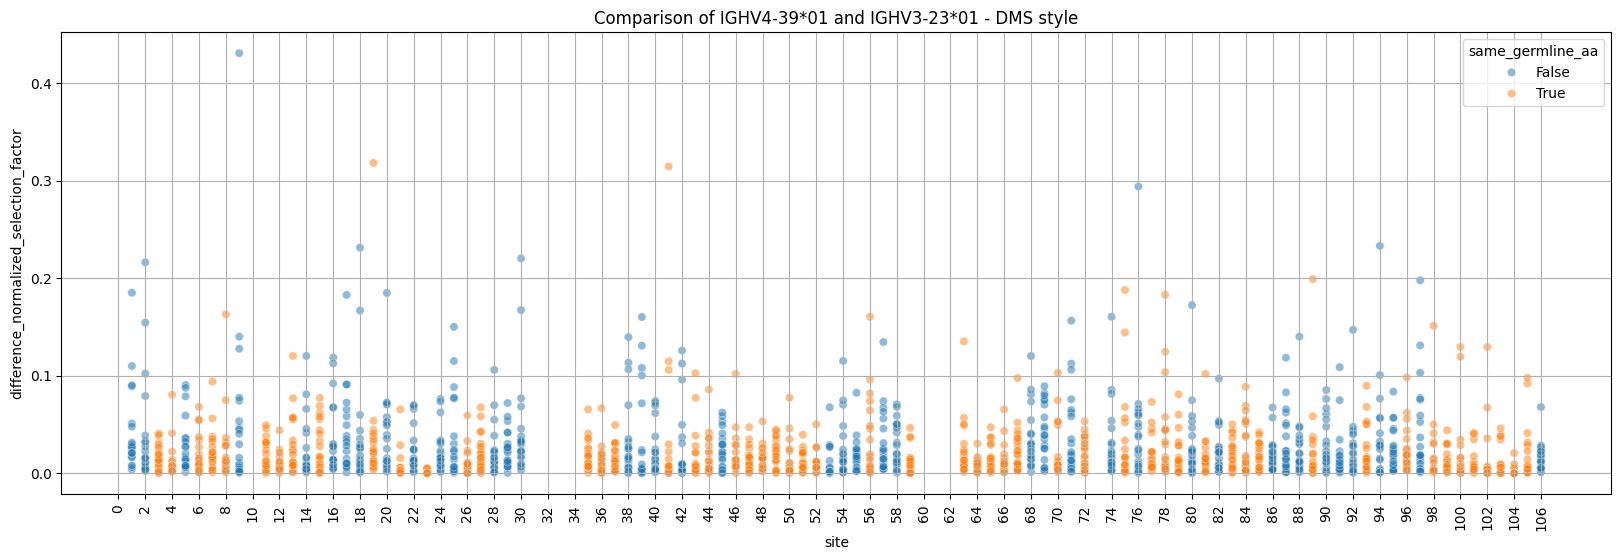

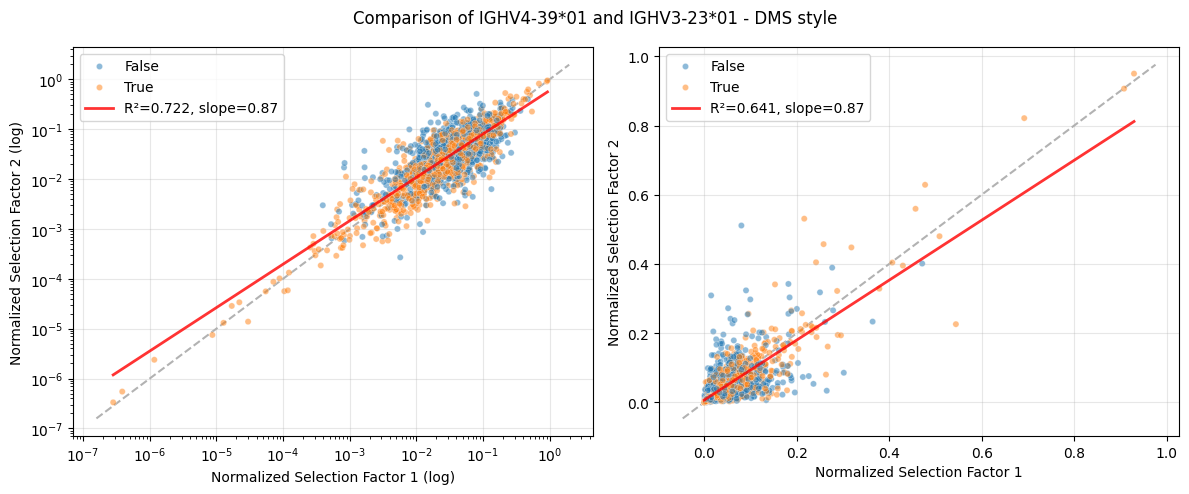

In [8]:
compare_df2 = compare_vgenes_dms_style(aa_site_subs_selection_df_germline, germline_codons_df, "IGHV4-39*01", "IGHV3-23*01", limit_pcp_depth=True, figsize=(20, 6))


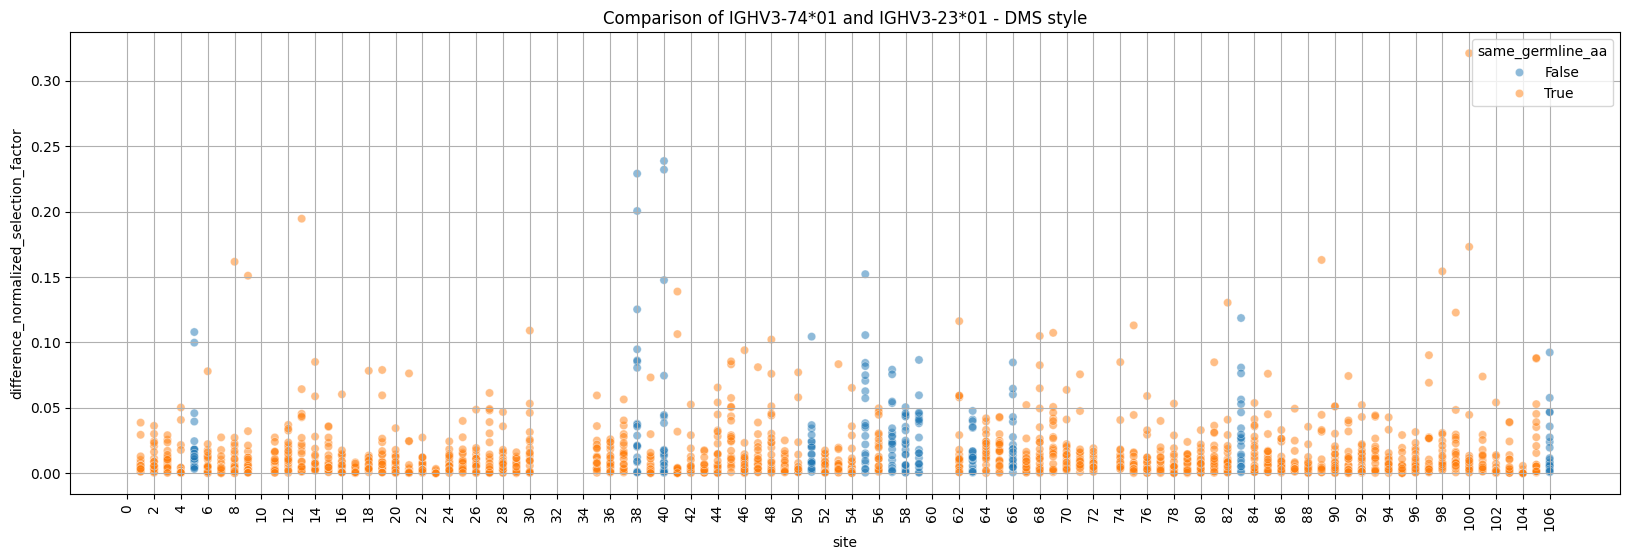

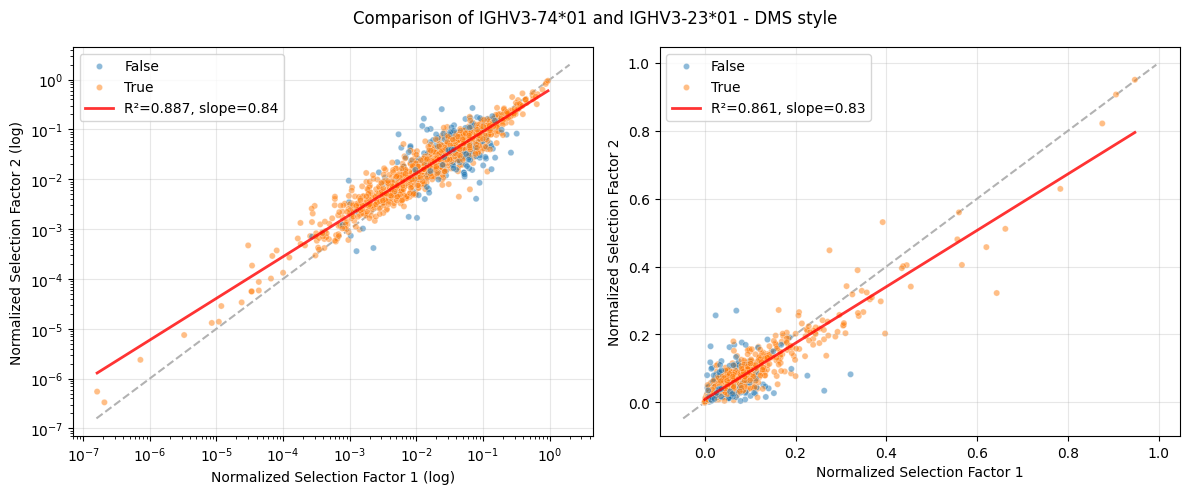

In [9]:
compare_df2 = compare_vgenes_dms_style(aa_site_subs_selection_df_germline, germline_codons_df, "IGHV3-74*01", "IGHV3-23*01", limit_pcp_depth=True, figsize=(20, 6))